<a href="https://colab.research.google.com/github/valerian-drmt/Trading_Projects/blob/main/LSTM_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Librairies and Raw Data

## 1.1 - Import Libraries

In [2]:
try:
    import vectorbt as vbt
except ImportError:
    print("vectorbt not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "vectorbt"])
    import vectorbt as vbt
    print("vectorbt installed successfully.")

try:
    import numpy as np
except ImportError:
    print("numpy not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "numpy"])
    import numpy as np
    print("numpy installed successfully.")

try:
    import pandas as pd
except ImportError:
    print("pandas not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "pandas"])
    import pandas as pd
    print("pandas installed successfully.")

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt
    print("matplotlib installed successfully.")

from datetime import datetime, timedelta  # No need to install datetime, it's a built-in module.

try:
    import yfinance as yf
except ImportError:
    print("yfinance not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "yfinance"])
    import yfinance as yf
    print("yfinance installed successfully.")

try:
    import torch
except ImportError:
    print("torch not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "torch"])
    import torch
    print("torch installed successfully.")

import torch.nn as nn  # No need to install nn, it's part of torch

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score # part of scikit-learn

try:
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
except ImportError:
    print("scikit-learn not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "scikit-learn"])
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    print("scikit-learn installed successfully.")

from scipy.stats import norm

try:
    from scipy.stats import norm
except ImportError:
    print("scipy not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "scipy"])
    from scipy.stats import norm
    print("scipy installed successfully.")


try:
    import plotly.express as px
except ImportError:
    print("plotly not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "plotly"])
    import plotly.express as px
    print("plotly installed successfully.")



try:
    import seaborn as sns
except ImportError:
    print("seaborn not found, installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "seaborn"])
    import seaborn as sns
    print("seaborn installed successfully.")

from sklearn.metrics import confusion_matrix # already imported above
from torch.utils.data import DataLoader, TensorDataset # already imported with torch
from torch.optim.lr_scheduler import ReduceLROnPlateau # already imported with torch
from torch.utils.data import random_split # already imported with torch

from collections import deque # No need to install collections, it's a built-in module.
import time
import os
import math
import psutil

print("All libraries imported or installed successfully.")


vectorbt not found, installing...
vectorbt installed successfully.
All libraries imported or installed successfully.


## 1.2 - Get Raw Data from API or File

In [5]:
def Get_Raw_Data(symbols, start, end, interval, With_file):
    import pandas as pd
    if not With_file:
      # Récupérer les données OHLCV depuis l'API Binance
      data_request = vbt.BinanceData.download(
          symbols= symbols,
          start = start,
          end = end,
          interval = interval
      )

      # Extraire les données OHLCV sous forme de DataFrame
      df = data_request.get()

      # Make sure the index is timezone-naive
      if df.index.tz is not None:
          df.index = df.index.tz_localize(None)

      # Also remove timezone from datetime columns (if any)
      for col in df.columns:
          if pd.api.types.is_datetime64tz_dtype(df[col]):
              df[col] = df[col].dt.tz_localize(None)

      # Save to Excel
      df.to_excel(f"BTCUSDT_{interval}.xlsx", index=True)
      print(f"BTCUSDT_{interval}.xlsx is in the folder")

      # Read Excel
      data_v0 = pd.read_excel(f"BTCUSDT_{interval}.xlsx").set_index("Open time")

    #---------------------------------------------------------------------------
    else:
      try:
          # Essayer d'importer le module google.colab pour vérifier si nous sommes dans Colab
          import google.colab
          Codelab = True  # Marquer comme étant dans Colab
      except ImportError:
          Codelab = False  # Si l'import échoue, définir Codelab sur False

      if Codelab:
          from google.colab import files
          uploaded = files.upload()  # Télécharger des fichiers

      # Assume that the uploaded file name is correct
      data_v0 = pd.read_excel(f"BTCUSDT_{interval}.xlsx")
      data_v0 = data_v0.set_index("Open time")

    return data_v0

## 1.3 - Test and Debug

| Interval       | Max Lookback Period (approx)  |
|----------------|-------------------------------|
| `'1m'`         | 7 days                        |
| `'2m'`         | 60 days                       |
| `'5m'`         | 60 days                       |
| `'15m'`        | 60 days                       |
| `'30m'`        | 60 days                       |
| `'60m'` / `'1h'` | 730 days (~2 years)        |
| `'1d'`         | ~20+ years                    |
| `'1wk'`        | ~20+ years                    |
| `'1mo'`        | ~20+ years                    |

In [6]:
With_file = True
symbols="BTCUSDT"
start="2025-02-03"
end="2025-04-06"
interval="1m"

data_v0 = Get_Raw_Data(symbols, start, end, interval, With_file)

print(data_v0.head())
print(data_v0.columns)
print("Shape:", data_v0.shape)

Saving BTCUSDT_1m.xlsx to BTCUSDT_1m.xlsx
                         Open      High       Low     Close    Volume  \
Open time                                                               
2025-02-02 22:00:00  97020.56  97245.54  96980.96  97245.54  38.56956   
2025-02-02 22:01:00  97245.54  97461.53  97245.53  97418.31  50.41245   
2025-02-02 22:02:00  97418.32  97514.46  97360.89  97376.62  31.50931   
2025-02-02 22:03:00  97376.62  97421.22  97300.00  97403.83  30.11589   
2025-02-02 22:04:00  97403.83  97501.97  97319.37  97443.72  38.74611   

                                 Close time  Quote volume  Number of trades  \
Open time                                                                     
2025-02-02 22:00:00 2025-02-02 22:00:59.999  3.745847e+06              9381   
2025-02-02 22:01:00 2025-02-02 22:01:59.999  4.908941e+06             11372   
2025-02-02 22:02:00 2025-02-02 22:02:59.999  3.070336e+06              8980   
2025-02-02 22:03:00 2025-02-02 22:03:59.999  2.9317

# 2 - Features Class

## 2.1 - Main Class

In [7]:
class LSTM_Features:
    def __init__(self, data):
        self.data = data

        methods = [resample_with_vwap, market_sessions, is_noise, Pivot_Points, Volume_Pivot_Points]
        for method in methods:
          method_name = method.__name__
          setattr(self, method_name, method.__get__(self))


## 2.2 - Definitions

### Resample with VWAP

In [8]:
def resample_with_vwap(self, resample_period: str = '5min'):
    df = self.data

    resampled = pd.DataFrame()
    resampled['Open'] = df['Open'].resample(resample_period).first()
    resampled['High'] = df['High'].resample(resample_period).max()
    resampled['Low'] = df['Low'].resample(resample_period).min()
    resampled['Close'] = df['Close'].resample(resample_period).last()
    resampled['Volume'] = df['Volume'].resample(resample_period).sum()
    resampled['Quote volume'] = df['Quote volume'].resample(resample_period).sum()
    resampled['Number of trades'] = df['Number of trades'].resample(resample_period).sum()
    resampled['Taker base volume'] = df['Taker base volume'].resample(resample_period).sum()
    resampled['Taker quote volume'] = df['Taker quote volume'].resample(resample_period).sum()

    # VWAP calculation from original data
    vwap_numerator = ((df['High']+df['Low']+df['Close'])/3 * df['Volume']).resample(resample_period).sum()
    vwap_denominator = df['Volume'].resample(resample_period).sum()
    resampled['VWAP_5m'] = vwap_numerator / vwap_denominator

    self.data = resampled  # safe overwrite after complete resampling
    return self

### Market Sessions

🕒 Market Opening Hours (Paris Time)

| Market     | Opening Hours (Paris Time) | Opening Hours (UTC) |
|------------|-----------------------------|----------------------|
| 🇭🇰 **Hong Kong / Tokyo** | 01:00 – 07:00                    | 00:00 – 06:00         |
| 🇬🇧 **London**            | 09:00 – 17:30                    | 08:00 – 16:30         |
| 🇺🇸 **New York**          | 15:30 – 22:00                    | 13:30 – 20:00         |

> ⚠️ Note: Hours may shift by 1 hour during daylight saving time transitions.

In [9]:
def market_sessions(self):
  # Make sure datetime index is correct
  self.data.index = pd.to_datetime(self.data.index)
  self.data.index = self.data.index.tz_localize(None)

  # Functions to check sessions
  def is_london_open(hour, minute):
      return (9 < hour < 17) or (hour == 17 and minute <= 30)

  def is_ny_open(hour, minute):
      return (16 <= hour < 22) or (hour == 15 and minute >= 30) or (hour == 22 and minute == 0)

  def is_tokyo_open(hour, minute):
      return (1 <= hour < 7)

  # Directly create session flags
  self.data['London_Open'] = self.data.index.map(lambda ts: int(is_london_open(ts.hour, ts.minute)))
  self.data['NY_Open'] = self.data.index.map(lambda ts: int(is_ny_open(ts.hour, ts.minute)))
  self.data['HK_Open'] = self.data.index.map(lambda ts: int(is_tokyo_open(ts.hour, ts.minute)))

  return self

### Is Noise

In [10]:
def is_noise(self, noise_ratio):
        df = self.data.copy()

        # Calcul de la range (High - Low)
        df['Range'] = df['High'] - df['Low']

        # Normalisation min-max
        vol_norm = (df['Volume'] - df['Volume'].min()) / (df['Volume'].max() - df['Volume'].min())
        range_norm = (df['Range'] - df['Range'].min()) / (df['Range'].max() - df['Range'].min())

        # Score de silence (plus c’est élevé, plus c’est du bruit potentiel)
        silence_score = (1 - vol_norm) + (1 - range_norm)
        df['Silence_Score'] = silence_score

        # Seuil automatique : garder les N% plus silencieuses
        threshold = df['Silence_Score'].quantile(1 - noise_ratio)
        df['Is_Noise'] = (df['Silence_Score'] >= threshold).astype(int)

        # Nettoyage
        df.drop(columns=['Range', 'Silence_Score'], inplace=True)

        self.data = df
        return self

### Pivot Points

In [11]:
def Pivot_Points(self, pivot_left, pivot_right):
    def clean_deque(i, k, deq, df, key, isHigh):
        if deq and deq[0] == i - k:
            deq.popleft()
        if isHigh:
            while deq and df.iloc[i][key] > df.iloc[deq[-1]][key]:
                deq.pop()
        else:
            while deq and df.iloc[i][key] < df.iloc[deq[-1]][key]:
                deq.pop()

    data = self.data[["High", "Low"]].copy()
    data['H'] = False
    data['L'] = False

    win_size = pivot_left + pivot_right + 1
    deqHigh = deque()
    deqLow = deque()

    max_idx = 0
    min_idx = 0
    i = 0
    j = pivot_left
    pivot_low = None
    pivot_high = None

    for index, row in data.iterrows():
        if i < win_size:
            clean_deque(i, win_size, deqHigh, data, 'High', True)
            clean_deque(i, win_size, deqLow, data, 'Low', False)
            deqHigh.append(i)
            deqLow.append(i)

            if data.iloc[i]['High'] > data.iloc[max_idx]['High']:
                max_idx = i
            if data.iloc[i]['Low'] < data.iloc[min_idx]['Low']:
                min_idx = i

            if i == win_size - 1:
                if data.iloc[max_idx]['High'] == data.iloc[j]['High']:
                    data.at[data.index[j], 'H'] = True
                    pivot_high = data.iloc[j]['High']
                if data.iloc[min_idx]['Low'] == data.iloc[j]['Low']:
                    data.at[data.index[j], 'L'] = True
                    pivot_low = data.iloc[j]['Low']
        else:
            j += 1
            clean_deque(i, win_size, deqHigh, data, 'High', True)
            clean_deque(i, win_size, deqLow, data, 'Low', False)
            deqHigh.append(i)
            deqLow.append(i)

            if data.iloc[deqHigh[0]]['High'] == data.iloc[j]['High']:
                data.at[data.index[j], 'H'] = True
                pivot_high = data.iloc[j]['High']
            if data.iloc[deqLow[0]]['Low'] == data.iloc[j]['Low']:
                data.at[data.index[j], 'L'] = True
                pivot_low = data.iloc[j]['Low']

        data.at[data.index[j], 'Last_High_Value'] = pivot_high
        data.at[data.index[j], 'Last_Low_Value'] = pivot_low
        i += 1

    # Drop helper columns
    data.drop(columns=['H', 'L'], inplace=True)

    # -------------------------------
    # Low pivot calculation
    lows_list = []
    broken_lows = []
    first_value_low = True
    data["Low_Pivot"] = np.nan

    for idx, row in data.iterrows():
        lows_list = [x for x in lows_list if not np.isnan(x)]
        last_low = row['Last_Low_Value']
        low = row['Low']

        if pd.notna(last_low):
            if first_value_low:
                lows_list.append(last_low)
                data.at[idx, "Low_Pivot"] = last_low
                first_value_low = False
                continue

            if not lows_list:
                if last_low not in broken_lows:
                    lows_list.append(last_low)
                    data.at[idx, "Low_Pivot"] = last_low
            elif len(lows_list) > 1:
                if low < lows_list[-1]:
                    broken_lows.append(lows_list.pop())
                if last_low not in broken_lows:
                    if last_low != lows_list[-1]:
                        lows_list.append(last_low)
                    data.at[idx, "Low_Pivot"] = lows_list[-1]
                else:
                    data.at[idx, "Low_Pivot"] = lows_list[-1]
            else:
                if low < lows_list[-1]:
                    broken_lows.append(lows_list.pop())
                    if last_low not in broken_lows:
                        lows_list.append(last_low)
                        data.at[idx, "Low_Pivot"] = last_low
                    else:
                        data.at[idx, "Low_Pivot"] = None
                else:
                    if last_low not in broken_lows:
                        if last_low != lows_list[-1]:
                            lows_list.append(last_low)
                        data.at[idx, "Low_Pivot"] = lows_list[-1]
                    else:
                        data.at[idx, "Low_Pivot"] = lows_list[-1]
        elif not first_value_low:
            if lows_list:
                if low < lows_list[-1]:
                    broken_lows.append(lows_list.pop())
                data.at[idx, "Low_Pivot"] = lows_list[-1] if lows_list else None

    # -------------------------------
    # High pivot calculation
    highs_list = []
    broken_highs = []
    first_value_high = True
    data["High_Pivot"] = np.nan

    for idx, row in data.iterrows():
        highs_list = [x for x in highs_list if not np.isnan(x)]
        last_high = row['Last_High_Value']
        high = row['High']

        if pd.notna(last_high):
            if first_value_high:
                highs_list.append(last_high)
                data.at[idx, "High_Pivot"] = last_high
                first_value_high = False
                continue

            if not highs_list:
                if last_high not in broken_highs:
                    highs_list.append(last_high)
                    data.at[idx, "High_Pivot"] = last_high
            elif len(highs_list) > 1:
                if high > highs_list[-1]:
                    broken_highs.append(highs_list.pop())
                if last_high not in broken_highs:
                    if last_high != highs_list[-1]:
                        highs_list.append(last_high)
                    data.at[idx, "High_Pivot"] = highs_list[-1]
                else:
                    data.at[idx, "High_Pivot"] = highs_list[-1]
            else:
                if high > highs_list[-1]:
                    broken_highs.append(highs_list.pop())
                    if last_high not in broken_highs:
                        highs_list.append(last_high)
                        data.at[idx, "High_Pivot"] = last_high
                    else:
                        data.at[idx, "High_Pivot"] = None
                else:
                    if last_high not in broken_highs:
                        if last_high != highs_list[-1]:
                            highs_list.append(last_high)
                        data.at[idx, "High_Pivot"] = highs_list[-1]
                    else:
                        data.at[idx, "High_Pivot"] = highs_list[-1]
        elif not first_value_high:
            if highs_list:
                if high > highs_list[-1]:
                    broken_highs.append(highs_list.pop())
                data.at[idx, "High_Pivot"] = highs_list[-1] if highs_list else None

    # -------------------------------
    # Update the class attribute with new pivot columns
    self.data["Low_Pivot"] = data["Low_Pivot"] - data["Low"]
    self.data["High_Pivot"] = data["High_Pivot"] - data["High"]

    return self

### Volume Pivot Points


In [13]:
def Volume_Pivot_Points(self, duration_min: int, n_cross: int = 7, std_factor: float = 1.0, plot_results: bool = True):

    df = self.data.copy()
    num_bars = duration_min // 5  # 5-minute candles

    typical_price = (df['High'] + df['Low'] + df['Close']) / 3
    rolling_num = (typical_price * df['Volume']).rolling(window=num_bars, min_periods=1).sum()
    rolling_den = df['Volume'].rolling(window=num_bars, min_periods=1).sum()

    vwap_col = f'Rolling_VWAP_{duration_min}min'
    df[vwap_col] = np.where(rolling_den != 0, rolling_num / rolling_den, np.nan)
    df[f'vitesse_{duration_min}min'] = df[vwap_col].diff()

    vitesse_col = f'vitesse_{duration_min}min'

    std = df[vitesse_col].std()
    mean = df[vitesse_col].mean()

    # UP crosses
    condition_up = df[vitesse_col] > mean + std_factor * std
    candidate_up = df.index[condition_up.shift(1).fillna(False, downcast='infer')]

    filtered_up = []
    for idx in candidate_up:
        if filtered_up and (df.index.get_loc(idx) - df.index.get_loc(filtered_up[-1]) <= n_cross):
            continue
        filtered_up.append(idx)

    df['vwap_cross_up'] = False
    df.loc[filtered_up, 'vwap_cross_up'] = True

    # DOWN crosses
    condition_down = df[vitesse_col] < mean - std_factor * std
    candidate_down = df.index[condition_down.shift(1).fillna(False, downcast='infer')]

    filtered_down = []
    for idx in candidate_down:
        if filtered_down and (df.index.get_loc(idx) - df.index.get_loc(filtered_down[-1]) <= n_cross):
            continue
        filtered_down.append(idx)

    df['vwap_cross_down'] = False
    df.loc[filtered_down, 'vwap_cross_down'] = True

    # Condition supplémentaire DOWN -> UP
    down_to_up = df.index[df['vwap_cross_down'] & (df["VWAP_5m"] > df['Rolling_VWAP_240min'])]
    df.loc[down_to_up, 'vwap_cross_down'] = False
    df.loc[down_to_up, 'vwap_cross_up'] = True

    # Condition supplémentaire UP -> DOWN
    up_to_down = df.index[df['vwap_cross_up'] & (df["VWAP_5m"] < df['Rolling_VWAP_240min'])]
    df.loc[up_to_down, 'vwap_cross_up'] = False
    df.loc[up_to_down, 'vwap_cross_down'] = True

    # ----------------------
    # Rolling VWAP High/Low Columns
    df['Rolling_Vwap_High'] = df[vwap_col].where(df['vwap_cross_up']).ffill()
    df['Rolling_Vwap_Low'] = df[vwap_col].where(df['vwap_cross_down']).ffill()

    # Add plotting data to the DataFrame: the y values for each plot
    df['plot_up_cross_y'] = df[vwap_col].where(df['vwap_cross_up'])
    df['plot_down_cross_y'] = df[vwap_col].where(df['vwap_cross_down'])

    # ----------------------
    # LAST CROSS PRICE
    df['last_volume_low_price'] = np.nan
    df['last_volume_high_price'] = np.nan

    last_down_price = np.nan
    last_up_price = np.nan

    for index, row in df.iterrows():
        if row['vwap_cross_down']:
            last_down_price = row[vwap_col]
        if row['vwap_cross_up']:
            last_up_price = row[vwap_col]

        df.loc[index, 'last_volume_high_price'] = last_down_price
        df.loc[index, 'last_volume_low_price'] = last_up_price

    # -------------------------------
    # Low pivot calculation
    lows_list = []
    broken_lows = []
    first_value_low = True
    df["Volume_Low_Pivot"] = np.nan

    for idx, row in df.iterrows():
        lows_list = [x for x in lows_list if not np.isnan(x)]
        last_low = row['last_volume_low_price']
        low = row['VWAP_5m']

        if pd.notna(last_low):
            if first_value_low:
                lows_list.append(last_low)
                df.at[idx, "Volume_Low_Pivot"] = last_low
                first_value_low = False
                continue

            if not lows_list:
                if last_low not in broken_lows:
                    lows_list.append(last_low)
                    df.at[idx, "Volume_Low_Pivot"] = last_low
            elif len(lows_list) > 1:
                if low < lows_list[-1]:
                    broken_lows.append(lows_list.pop())
                if last_low not in broken_lows:
                    if last_low != lows_list[-1]:
                        lows_list.append(last_low)
                    df.at[idx, "Volume_Low_Pivot"] = lows_list[-1]
                else:
                    df.at[idx, "Volume_Low_Pivot"] = lows_list[-1]
            else:
                if low < lows_list[-1]:
                    broken_lows.append(lows_list.pop())
                    if last_low not in broken_lows:
                        lows_list.append(last_low)
                        df.at[idx, "Volume_Low_Pivot"] = last_low
                    else:
                        df.at[idx, "Volume_Low_Pivot"] = None
                else:
                    if last_low not in broken_lows:
                        if last_low != lows_list[-1]:
                            lows_list.append(last_low)
                        df.at[idx, "Volume_Low_Pivot"] = lows_list[-1]
                    else:
                        df.at[idx, "Volume_Low_Pivot"] = lows_list[-1]
        elif not first_value_low:
            if lows_list:
                if low < lows_list[-1]:
                    broken_lows.append(lows_list.pop())
                df.at[idx, "Volume_Low_Pivot"] = lows_list[-1] if lows_list else None

    # -------------------------------
    # High pivot calculation
    highs_list = []
    broken_highs = []
    first_value_high = True
    df["Volume_High_Pivot"] = np.nan

    for idx, row in df.iterrows():
        highs_list = [x for x in highs_list if not np.isnan(x)]
        last_high = row['last_volume_high_price']
        high = row['VWAP_5m']

        if pd.notna(last_high):
            if first_value_high:
                highs_list.append(last_high)
                df.at[idx, "Volume_High_Pivot"] = last_high
                first_value_high = False
                continue

            if not highs_list:
                if last_high not in broken_highs:
                    highs_list.append(last_high)
                    df.at[idx, "Volume_High_Pivot"] = last_high
            elif len(highs_list) > 1:
                if high > highs_list[-1]:
                    broken_highs.append(highs_list.pop())
                if last_high not in broken_highs:
                    if last_high != highs_list[-1]:
                        highs_list.append(last_high)
                    df.at[idx, "Volume_High_Pivot"] = highs_list[-1]
                else:
                    df.at[idx, "Volume_High_Pivot"] = highs_list[-1]
            else:
                if high > highs_list[-1]:
                    broken_highs.append(highs_list.pop())
                    if last_high not in broken_highs:
                        highs_list.append(last_high)
                        df.at[idx, "Volume_High_Pivot"] = last_high
                    else:
                        df.at[idx, "Volume_High_Pivot"] = None
                else:
                    if last_high not in broken_highs:
                        if last_high != highs_list[-1]:
                            highs_list.append(last_high)
                        df.at[idx, "Volume_High_Pivot"] = highs_list[-1]
                    else:
                        df.at[idx, "Volume_High_Pivot"] = highs_list[-1]
        elif not first_value_high:
            if highs_list:
                if high > highs_list[-1]:
                    broken_highs.append(highs_list.pop())
                df.at[idx, "Volume_High_Pivot"] = highs_list[-1] if highs_list else None

    # -------------------------------
    # Update the class attribute with new pivot columns
    colonnes_a_supprimer = ['vitesse_240min', 'vwap_cross_up', 'vwap_cross_down',
                        'Rolling_Vwap_High', 'Rolling_Vwap_Low',
                        'plot_up_cross_y', 'plot_down_cross_y']

    df = df.drop(colonnes_a_supprimer, axis=1)

    df["Volume_Low_Pivot"] = df["VWAP_5m"] - df["Volume_Low_Pivot"]
    df["Volume_High_Pivot"] = df["Volume_High_Pivot"] - df["VWAP_5m"]

    self.data = df.copy()
    return self

## 2.3 - Test and Debug

<ipython-input-13-53e6759254ce>:21: FutureWarning: The 'downcast' keyword in fillna is deprecated and will be removed in a future version. Use res.infer_objects(copy=False) to infer non-object dtype, or pd.to_numeric with the 'downcast' keyword to downcast numeric results.
  candidate_up = df.index[condition_up.shift(1).fillna(False, downcast='infer')]
<ipython-input-13-53e6759254ce>:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  candidate_up = df.index[condition_up.shift(1).fillna(False, downcast='infer')]
<ipython-input-13-53e6759254ce>:34: FutureWarning: The 'downcast' keyword in fillna is deprecated and will be removed in a future version. Use res.infer_objects(copy=False) to infer non-object dtype, or pd.to_numeric with the 'downcast' keyword to downcast numeric

#----------------------------------------------------------------------
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Quote volume',
       'Number of trades', 'Taker base volume', 'Taker quote volume',
       'VWAP_5m', 'London_Open', 'NY_Open', 'HK_Open', 'Is_Noise', 'Low_Pivot',
       'High_Pivot', 'Rolling_VWAP_240min', 'last_volume_low_price',
       'last_volume_high_price', 'Volume_Low_Pivot', 'Volume_High_Pivot'],
      dtype='object')
#----------------------------------------------------------------------
                         Open      High       Low     Close     Volume  \
Open time                                                                
2025-04-04 04:20:00  82643.53  82716.97  82615.36  82716.97   23.60498   
2025-04-04 04:25:00  82716.97  82813.94  82716.96  82804.32   24.09416   
2025-04-04 04:30:00  82804.32  82917.68  82710.09  82916.35  152.22247   
2025-04-04 04:35:00  82916.36  82920.19  82827.10  82871.80   29.26932   
2025-04-04 04:40:00  82871.80  

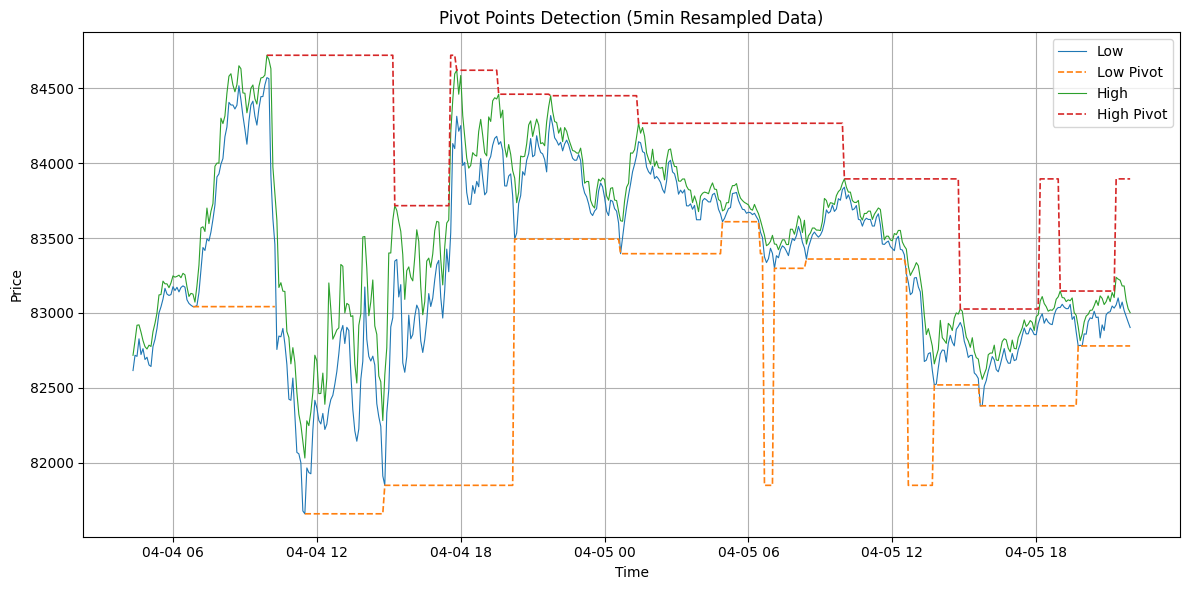

#----------------------------------------------------------------------


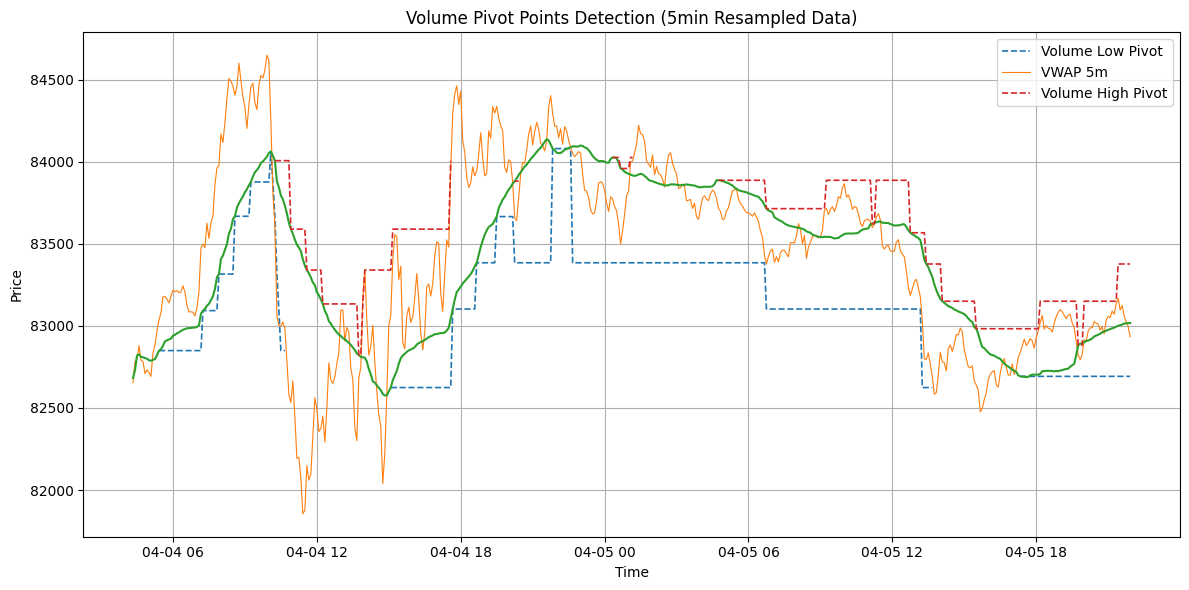

#----------------------------------------------------------------------


In [18]:
#-------------------------------------------------------------------------------
# Step 0: Initialize Features Dataframe
Features_Data = LSTM_Features(data_v0[-2500:])

# Step 1: Market Sessions
resample_period = '5min'
Features_Data.resample_with_vwap(resample_period)

# Step 2: Market Sessions
Features_Data.market_sessions()

# Step 3: Is Noise
noise_ratio = 0.15
Features_Data.is_noise(noise_ratio)

# Step 4: Pivot Points
pivot_left = 15
pivot_right = 15
Features_Data.Pivot_Points(pivot_left, pivot_right)

# Step 5: Volume Pivot Points
duration_min = 240
n_cross = 7
std_factor = 1.0
Features_Data.Volume_Pivot_Points(duration_min, n_cross, std_factor)
#-------------------------------------------------------------------------------

print("#----------------------------------------------------------------------")
print(Features_Data.data.columns)
print("#----------------------------------------------------------------------")
print(Features_Data.data.head())
print("#----------------------------------------------------------------------")

debug1 = False
debug2 = False
debug3 = False
debug4 = True
debug5 = True

if debug1:
    print("Shape:", Features_Data.data.shape)
    print("Columns:", Features_Data.data.columns[:5].tolist(), "...")  # Show only first 5 columns

    # Additional Analysis Market Sessions (Reduced output)
    frequency = Features_Data.data[["London_Open", "NY_Open", "HK_Open"]].apply(
        lambda col: pd.Series(col).value_counts()
    ).fillna(0).astype(int)
    print("\nSession Open/Close Frequency (Top 3):")
    print(frequency.head(3))  # Show only the top 3 rows

    # Additional Analysis Is Noise
    frequency = Features_Data.data["Is_Noise"].value_counts().sort_index()
    print("\nNoise Label Frequency:")
    print(frequency)

    # Plotting
    nb = 500
    plt.figure(figsize=(12, 4))
    plt.plot(Features_Data.data["London_Open"].iloc[:nb], label="London")
    plt.plot(Features_Data.data["NY_Open"].iloc[:nb], label="New York")
    plt.plot(Features_Data.data["HK_Open"].iloc[:nb], label="Hong Kong")
    plt.legend()
    plt.title(f"Market Sessions from Index 0 to {nb}")
    plt.xlabel("Time")
    plt.ylabel("Market Open (1 = open, 0 = closed)")
    plt.show()
    print("#----------------------------------------------------------------------")

if debug4:
    pivot_data = Features_Data.data

    # Affichage des courbes
    plt.figure(figsize=(12, 6))
    plt.plot(pivot_data["Low"], label="Low", linewidth=0.8)
    plt.plot(pivot_data["Low_Pivot"] + pivot_data["Low"], label="Low Pivot", linewidth=1.2, linestyle='--')
    plt.plot(pivot_data["High"], label="High", linewidth=0.8)
    plt.plot(pivot_data["High_Pivot"] + pivot_data["High"], label="High Pivot", linewidth=1.2, linestyle='--')
    plt.legend()
    plt.title("Pivot Points Detection (5min Resampled Data)")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("#----------------------------------------------------------------------")

if debug5:
    # Affichage des courbes
    plt.figure(figsize=(12, 6))
    plt.plot(Features_Data.data["VWAP_5m"] - Features_Data.data["Volume_Low_Pivot"] , label="Volume Low Pivot", linewidth=1.2, linestyle='--')
    plt.plot(Features_Data.data["VWAP_5m"], label="VWAP 5m", linewidth=0.8)
    plt.plot(Features_Data.data['Rolling_VWAP_240min'])
    plt.plot(Features_Data.data["Volume_High_Pivot"] + Features_Data.data["VWAP_5m"], label="Volume High Pivot", linewidth=1.2, linestyle='--')
    plt.legend()
    plt.title("Volume Pivot Points Detection (5min Resampled Data)")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("#----------------------------------------------------------------------")

# Last Step: Refresh Data
Features_Data.data = None

# 3 - Labels Class

## 3.1 - Main Class

In [ ]:
class LSTM_Labels():
    def __init__(self, data , look_forward :int, n_categories : int):
        self.data = data
        self.look_forward = look_forward
        self.n_categories = n_categories
        self.boundaries = None

        methods = [categorize_with_std]
        for method in methods:
          method_name = method.__name__
          setattr(self, method_name, method.__get__(self))

## 3.2 - Definitions

### Categorize with std

In [ ]:
def categorize_with_std(self):

        # 1. Calculate the Return and the Z-Score
        self.data["Return"] = self.data["Price"].shift(-self.look_forward) / self.data["Price"] - 1
        mean = self.data["Return"].mean()
        std = self.data["Return"].std()
        self.data["Return Z-Score"] = (self.data["Return"] - mean) / std

        # 2. Define category boundaries based on standard deviation multiples
        n = self.n_categories
        max_std = 3  # Cover most of the normal distribution (-3σ to +3σ)
        self.boundaries = np.linspace(-max_std, max_std, n + 1)


        # 3. Calculate frequencies assuming normal distribution
        category_frequencies = []
        for i in range(len(self.boundaries) - 1):
            prob = norm.cdf(self.boundaries[i + 1]) - norm.cdf(self.boundaries[i])
            category_frequencies.append(prob)

        category_frequencies = np.array(category_frequencies)

        # 4. Function to categorize a Z-score
        def categorize_zscore(z, bounds):
            if pd.isna(z):
                return np.nan
            for i in range(len(bounds) - 1):
                if bounds[i] <= z < bounds[i + 1]:
                    return i
            return np.nan  # In case z is outside boundaries due to numerical issues

        # 5. Create Category_Close (current Return Z-Score category)
        self.data["Category_Close"] = self.data["Return Z-Score"].apply(lambda z: categorize_zscore(z, self.boundaries))

        # 6. Calculate High and Low Z-Scores over the past 20 candles
        self.data["High_20"] = self.data["Price"].rolling(window=20).max()
        self.data["Low_20"] = self.data["Price"].rolling(window=20).min()

        self.data["High_20_Return"] = self.data["High_20"].shift(-self.look_forward) / self.data["Price"] - 1
        self.data["Low_20_Return"] = self.data["Low_20"].shift(-self.look_forward) / self.data["Price"] - 1

        self.data["High_20_Z-Score"] = (self.data["High_20_Return"] - mean) / std
        self.data["Low_20_Z-Score"] = (self.data["Low_20_Return"] - mean) / std

        # 7. Create Category_High and Category_Low
        self.data["Category_High"] = self.data["High_20_Z-Score"].apply(lambda z: categorize_zscore(z, self.boundaries))
        self.data["Category_Low"] = self.data["Low_20_Z-Score"].apply(lambda z: categorize_zscore(z, self.boundaries))

        # 8. Clean up intermediate columns if you want (optional)
        self.data.drop(columns=["Return", "Return Z-Score", "High_20", "Low_20", "High_20_Return", "Low_20_Return", "High_20_Z-Score", "Low_20_Z-Score"], inplace=True)

        return self

## 3.2 - Test and debug

                         Open      High       Low     Close     Volume  \
Open time                                                                
2025-02-02 22:00:00  97020.56  97514.46  96980.96  97443.72  189.35332   
2025-02-02 22:05:00  97443.72  97533.33  97333.01  97527.98  116.98419   
2025-02-02 22:10:00  97527.98  97709.18  97471.37  97509.53   89.81456   
2025-02-02 22:15:00  97509.53  97732.30  97466.16  97542.21  113.01349   
2025-02-02 22:20:00  97542.20  97551.96  97171.99  97427.81   97.60148   

                     Quote volume  Number of trades  Taker base volume  \
Open time                                                                
2025-02-02 22:00:00  1.843028e+07             43294          103.22025   
2025-02-02 22:05:00  1.139881e+07             26472           49.60370   
2025-02-02 22:10:00  8.765448e+06             19690           46.41396   
2025-02-02 22:15:00  1.102917e+07             20238           54.01778   
2025-02-02 22:20:00  9.502910e+06    

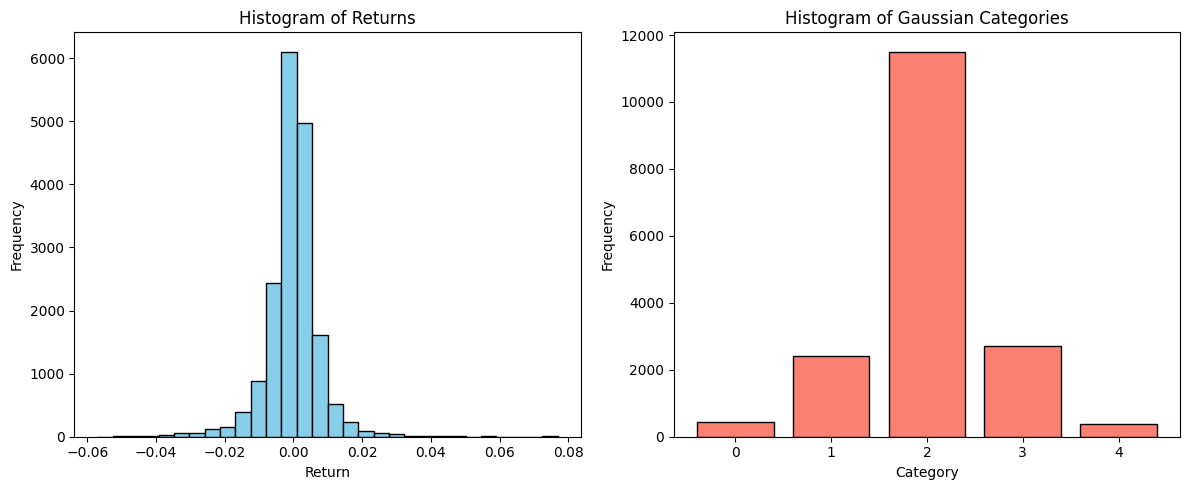

In [ ]:
Features_Data = LSTM_Features(data_v0).resample_with_vwap("5min").is_noise(0.2)

#------------------------------------------------------------------------

Labels_Data = LSTM_Labels(Features_Data.data, look_forward = 20, n_categories = 5)
Labels_Data.data["Price"] = Labels_Data.data["VWAP_5m"]
Labels_Data.categorize_with_std()

print(Labels_Data.data.head())
print("Boudaries: ", Labels_Data.boundaries)

# Count the number of points (no normalization)
close_counts = Labels_Data.data["Category_Close"].value_counts(normalize=False).sort_index()
high_counts = Labels_Data.data["Category_High"].value_counts(normalize=False).sort_index()
low_counts = Labels_Data.data["Category_Low"].value_counts(normalize=False).sort_index()
print(close_counts.shape, high_counts.shape, low_counts.shape)
"""
table = pd.DataFrame({
    'Low Count': low_counts.values,
    'Close Count': close_counts.values,
    'High Count': high_counts.values
}, index=close_counts.index)
print(table)"""

# Verification
plt.figure(figsize=(12, 5))

# Histogramme des future returns
plt.subplot(1, 2, 1)
plt.hist(Labels_Data.data["Price"].pct_change(Labels_Data.look_forward).dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Histogram of Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")

# Histogramme des catégories gaussiennes
plt.subplot(1, 2, 2)
plt.hist(Labels_Data.data["Category_Close"].dropna(), bins=np.arange(Labels_Data.n_categories + 1) - 0.5, color='salmon', edgecolor='black', rwidth=0.8)
plt.xticks(range(Labels_Data.n_categories))
plt.title("Histogram of Gaussian Categories")
plt.xlabel("Category")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Last Step: Refresh Data
Features_Data.data = None
Labels_Data.data = None

# 4 - Split Data to get Train/Test

## 4.1 - Definition

In [ ]:
def split_data(train_test_data, lookback, size_test_prct):
    # 1. Split automatically: features = columns starting with "Feature_", labels = columns starting with "Label_"
    feature_cols = [col for col in train_test_data.columns if col.startswith("Feature")]
    label_cols = [col for col in train_test_data.columns if col.startswith("Label")]

    # 2. Convert to numpy arrays
    features = train_test_data[feature_cols].values  # shape (N, n_features)
    labels = train_test_data[label_cols].values      # shape (N, n_labels)

    # 3. Normalize only the features (per feature column)
    features = (features - features.min(axis=0)) / (features.max(axis=0) - features.min(axis=0))

    # 4. Stack features and labels together
    data_all = np.hstack((features, labels))  # shape (N, n_features + n_labels)

    # 5. Create sequences
    data = []
    for index in range(len(data_all) - lookback):
        data.append(data_all[index: index + lookback])

    data = np.array(data)  # shape (num_sequences, lookback, n_features + n_labels)

    # 6. Split train / test
    test_set_size = int(np.round(size_test_prct * data.shape[0]))
    train_set_size = data.shape[0] - test_set_size

    # ➔ x = all features
    # ➔ y = all labels
    x_train = data[:train_set_size, :, :len(feature_cols)]    # Take only features
    y_train = data[:train_set_size, -1, len(feature_cols):]    # Take only labels (last time step)
    x_test = data[train_set_size:, :, :len(feature_cols)]
    y_test = data[train_set_size:, -1, len(feature_cols):]

    # 7. Convert to PyTorch tensors
    x_train = torch.from_numpy(x_train).float()
    y_train = torch.from_numpy(y_train).long()
    x_test = torch.from_numpy(x_test).float()
    y_test = torch.from_numpy(y_test).long()

    return x_train, y_train, x_test, y_test

## 4.2 - Test and Debug

In [ ]:
lookback = 100
size_test_prct = 0.3
#------------------------------------------------------------------------

Features_Data = LSTM_Features(data_v0).resample_with_vwap("5min").market_sessions()

#------------------------------------------------------------------------

Labels_Data = LSTM_Labels(Features_Data.data, look_forward = 20, n_categories = 5)
Labels_Data.data["Price"] = Labels_Data.data["Close"]
Labels_Data.categorize_with_std()

#-------------------------------------------------------------------------------

train_test_data = pd.DataFrame({"Feature_1": Labels_Data.data["VWAP_5m"],
                                "Feature_2": Labels_Data.data["London_Open"],
                                "Feature_3": Labels_Data.data["NY_Open"],
                                "Feature_4": Labels_Data.data["HK_Open"],
                                "Label_1": Labels_Data.data["Category_Low"],
                                "Label_2": Labels_Data.data["Category_Close"],
                                "Label_3": Labels_Data.data["Category_High"]
                                }).dropna()

x_train, y_train, x_test, y_test = split_data(train_test_data, lookback, size_test_prct)

#-------------------------------------------------------------------------------
#Verification

debug = True
if debug:
  print("-----------------------------------------------------------------------")
  print("Feature Columns: ",Features_Data.data.columns)
  print("-----------------------------------------------------------------------")
  print(Labels_Data.data.head())
  print("-----------------------------------------------------------------------")
  print("Label Columns: ", Labels_Data.data.columns)
  print("-----------------------------------------------------------------------")
  print("Test Train Columns: ", train_test_data.columns)
  print("-----------------------------------------------------------------------")
  print("Train: ",x_train.shape, y_train.shape)
  print("Test: ",x_test.shape, y_test.shape)
  print("-----------------------------------------------------------------------")
  counts = pd.Series(y_test[:, 1].cpu().numpy()).value_counts(normalize=False).sort_index()
  table = pd.DataFrame({
      'Count': counts.values,
  }, index=counts.index)
  print(table)
  print("-----------------------------------------------------------------------")
  for i in range(y_train.shape[1]):  # Loop over each label
    print(f"Label {i}:")
    print(pd.Series(y_train[:, i].cpu().numpy()).value_counts(normalize=False).sort_index())
    print()

-----------------------------------------------------------------------
Feature Columns:  Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Quote volume',
       'Number of trades', 'Taker base volume', 'Taker quote volume',
       'VWAP_5m', 'London_Open', 'NY_Open', 'HK_Open', 'Price',
       'Category_Close', 'Category_High', 'Category_Low'],
      dtype='object')
-----------------------------------------------------------------------
                         Open      High       Low     Close     Volume  \
Open time                                                                
2025-02-02 22:00:00  97020.56  97514.46  96980.96  97443.72  189.35332   
2025-02-02 22:05:00  97443.72  97533.33  97333.01  97527.98  116.98419   
2025-02-02 22:10:00  97527.98  97709.18  97471.37  97509.53   89.81456   
2025-02-02 22:15:00  97509.53  97732.30  97466.16  97542.21  113.01349   
2025-02-02 22:20:00  97542.20  97551.96  97171.99  97427.81   97.60148   

                     Quote volume  Numb

# 5 - LSTM Class

## 5.1 - Main Class

In [ ]:
class LSTM(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim, num_epochs, n_labels, n_categories, dropout_p=0.3):
    super(LSTM, self).__init__()

    self.num_layers = num_layers
    self.lstm_layers = nn.ModuleList()
    self.dropout_layers = nn.ModuleList()
    self.num_epochs = num_epochs
    self.n_labels = n_labels
    self.n_categories = n_categories

    self.criterion = None

    # Tracking metrics
    self.hist_criterion = []
    self.hist_acc = []
    self.hist_f1 = []
    self.hist_precision = []
    self.hist_recall = []


    # Build LSTM layers + Dropout layers
    self.lstm_layers.append(nn.LSTM(input_dim, hidden_dim[0], batch_first=True))
    self.dropout_layers.append(nn.Dropout(p=dropout_p))

    for i in range(1, self.num_layers):
        self.lstm_layers.append(nn.LSTM(hidden_dim[i-1], hidden_dim[i], batch_first=True))
        self.dropout_layers.append(nn.Dropout(p=dropout_p))

    self.fc = nn.Linear(hidden_dim[-1], output_dim)

    #---------------------------------------------------------------------------
    #Add all definitions
    methods = [forward, multi_task_loss, update_metrics, get_pred, show_metrics, visualize_classification_results]

    for method in methods:
      method_name = method.__name__
      setattr(self, method_name, method.__get__(self))


## 5.2 - Definitions

### Forward

In [ ]:
def forward(self, x):
    out = x
    for lstm, dropout in zip(self.lstm_layers, self.dropout_layers):
        out, _ = lstm(out)
        out = dropout(out)  # Apply Dropout after each LSTM

    out = out[:, -1, :]  # Take the last output
    out = self.fc(out)   # Shape: (batch_size, output_dim = n_labels * n_categories)

    # Split output into n_labels parts (e.g., 3 parts of 7 classes)
    out_split = torch.split(out, self.n_categories, dim=1)  # List of tensors [(batch, 7), (batch, 7), (batch, 7)]

    return out_split  # tuple of outputs per task

### Multi-Task Loss

In [ ]:
def multi_task_loss(self, outputs, targets):
    """
    Compute average CrossEntropyLoss over multiple outputs.
    - outputs: list of tensors (batch_size, n_categories)
    - targets: tensor (batch_size, n_labels) with class indices
    """
    loss_fn = nn.CrossEntropyLoss()
    losses = [
        loss_fn(output, targets[:, i])
        for i, output in enumerate(outputs)
    ]
    return sum(losses) / len(losses)

### Update Metrics

In [ ]:
def update_metrics(self, y_train_pred, y_train):

        total_loss = 0
        y_pred_list = []
        y_true_list = []

        for i in range(self.n_labels):
            pred = y_train_pred[:, i*self.n_categories:(i+1)*self.n_categories]
            true = y_train[:, i]
            loss = self.criterion(pred, true)
            total_loss += loss / self.n_labels

            pred_classes = torch.argmax(pred, dim=1)
            y_pred_list.append(pred_classes.detach().cpu().numpy())
            y_true_list.append(true.detach().cpu().numpy())

        # Concatenate all predictions and truths
        y_pred_np = np.concatenate(y_pred_list)
        y_true_np = np.concatenate(y_true_list)

        acc = accuracy_score(y_true_np, y_pred_np)
        f1 = f1_score(y_true_np, y_pred_np, average='weighted')
        prec = precision_score(y_true_np, y_pred_np, average='weighted', zero_division=0)
        rec = recall_score(y_true_np, y_pred_np, average='weighted', zero_division=0)

        self.hist_criterion.append(total_loss.item())
        self.hist_acc.append(acc)
        self.hist_f1.append(f1)
        self.hist_precision.append(prec)
        self.hist_recall.append(rec)

        return total_loss

### Get Predicion

In [ ]:
def get_pred(self, x_test):
    self.eval()
    with torch.no_grad():
        y_pred_split = self(x_test)  # tuple/list of n_labels tensors
        y_pred_concat = torch.cat(y_pred_split, dim=1)  # (batch_size, n_labels * n_categories)

    y_test_pred = []
    for i in range(self.n_labels):
        pred = y_pred_concat[:, i * self.n_categories : (i + 1) * self.n_categories]
        pred_class = torch.argmax(pred, dim=1)
        y_test_pred.append(pred_class)

    y_test_pred = torch.stack(y_test_pred, dim=1)  # (batch_size, n_labels)

    return y_test_pred, y_pred_concat


### Show Metrics

In [ ]:
def show_metrics(self, y_test, y_test_pred, y_test_pred_list):
    # Conversion en NumPy
    y_test_np = y_test.detach().cpu().numpy()
    y_test_pred_np = y_test_pred.detach().cpu().numpy()

    # Flatten to compare all labels
    y_test_np = y_test_np.flatten()
    y_test_pred_np = y_test_pred_np.flatten()

    # Métriques test
    acc_test = accuracy_score(y_test_np, y_test_pred_np)
    f1_test = f1_score(y_test_np, y_test_pred_np, average='weighted')
    precision_test = precision_score(y_test_np, y_test_pred_np, average='weighted', zero_division=0)
    recall_test = recall_score(y_test_np, y_test_pred_np, average='weighted', zero_division=0)

    total_loss = 0
    for i in range(self.n_labels):
        pred = y_test_pred_list[:, i*self.n_categories:(i+1)*self.n_categories]
        true = y_test[:, i]
        loss = self.criterion(pred, true)
        total_loss += loss / self.n_labels
    loss_test = total_loss.item()

    # Moyenne des métriques train
    acc_train = np.mean(self.hist_acc[-int(self.num_epochs * 0.2):])
    f1_train = np.mean(self.hist_f1[-int(self.num_epochs * 0.2):])
    precision_train = np.mean(self.hist_precision[-int(self.num_epochs * 0.2):])
    recall_train = np.mean(self.hist_recall[-int(self.num_epochs * 0.2):])
    loss_train = np.mean(self.hist_criterion[-int(self.num_epochs * 0.2):])

    # Tableau final
    metrics_data = {
        'Train': [acc_train, f1_train, precision_train, recall_train, loss_train],
        'Test':  [acc_test, f1_test, precision_test, recall_test, loss_test]
    }

    metrics_df = pd.DataFrame(metrics_data, index=['Accuracy', 'F1-score', 'Precision', 'Recall', 'Loss'])

    print("\n📊 Résumé des métriques de classification :\n")
    print(metrics_df.round(4))

    print("---------------------------------")
    print("Accuracy = proportion de prédictions correctes sur l’ensemble des classes.")
    print("Precision = parmi les prédictions positives, combien sont réellement correctes.")
    print("Recall = parmi les vrais positifs, combien le modèle a réussi à capturer.")
    print("F1-score = compromis entre precision et recall, utile en cas de classes déséquilibrées.")
    print("Loss = mesure l’erreur globale du modèle, plus elle est basse, mieux c’est.")
    print("---------------------------------")

    # Plot Metrics
    metrics = [self.hist_criterion, self.hist_acc, self.hist_f1, self.hist_precision, self.hist_recall]
    titles = ['CrossEntropy Loss', 'Accuracy', 'F1-score', 'Precision', 'Recall']
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    ylabel = ['Score'] * 4 + ['Loss']

    epochs = range(1, len(self.hist_acc) + 1)
    fig, axs = plt.subplots(1, 5, figsize=(22, 4))

    for i, ax in enumerate(axs):
        ax.plot(epochs, metrics[i], color=colors[i])
        ax.set_title(titles[i])
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel[i])
        ax.grid(True)

    plt.tight_layout()
    plt.suptitle('Training Metrics per Epoch', fontsize=16, y=1.05)
    plt.show()

    return self

### Visualize Classification Results

In [ ]:
def visualize_classification_results(self, y_true, y_pred, n_categories, sequence_title="True vs Predicted", max_points=150):
    """
    Displays for each label dimension:
    - Confusion matrix (heatmap)
    - Class sequence (true vs pred)
    - Histogram of class distribution
    """

    # Convert to NumPy if Tensors
    if hasattr(y_true, 'detach'):
        y_true = y_true.detach().cpu().numpy()
    if hasattr(y_pred, 'detach'):
        y_pred = y_pred.detach().cpu().numpy()

    # If labels are 1D, add a dimension
    if y_true.ndim == 1:
        y_true = y_true[:, None]
        y_pred = y_pred[:, None]

    n_labels = y_true.shape[1]

    for label_idx in range(n_labels):
        print(f"Plotting for label {label_idx}")

        true_label = y_true[:, label_idx].flatten()
        pred_label = y_pred[:, label_idx].flatten()

        # Create figure with 3 side-by-side subplots
        fig, axs = plt.subplots(1, 3, figsize=(22, 5))
        plt.subplots_adjust(wspace=0.4)

        # 1. Confusion Matrix
        cm = confusion_matrix(true_label, pred_label, labels=range(n_categories))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=range(n_categories),
                    yticklabels=range(n_categories),
                    ax=axs[0])
        axs[0].set_xlabel("Predicted")
        axs[0].set_ylabel("Actual")
        axs[0].set_title(f"Confusion Matrix (Label {label_idx})")

        # 2. Class sequence
        axs[1].plot(true_label[-max_points:], label='True', marker='o')
        axs[1].plot(pred_label[-max_points:], label='Predicted', marker='x', linestyle='--')
        axs[1].set_title(f"{sequence_title} (Label {label_idx}) (last {max_points} samples)")
        axs[1].set_xlabel("Sample Index")
        axs[1].set_ylabel("Class")
        axs[1].legend()
        axs[1].grid(True)

        # 3. Histogram of classes
        true_counts = pd.Series(true_label).value_counts().sort_index().reindex(range(n_categories), fill_value=0)
        pred_counts = pd.Series(pred_label).value_counts().sort_index().reindex(range(n_categories), fill_value=0)

        bar_width = 0.35
        classes = np.arange(n_categories)

        axs[2].bar(classes - bar_width/2, true_counts, width=bar_width, label='True Labels')
        axs[2].bar(classes + bar_width/2, pred_counts, width=bar_width, label='Predicted Labels')
        axs[2].set_xlabel("Class")
        axs[2].set_ylabel("Count")
        axs[2].set_title(f"Class Distribution (Label {label_idx})")
        axs[2].set_xticks(classes)
        axs[2].legend()
        axs[2].grid(axis='y')

        plt.show()


# 6 - LSTM Performance Class

In [ ]:
def suggest_batch_size(n_samples, n_features, n_labels, lookback, reserved_ram_gb, hidden_dim, num_layers):
    """
    Suggests a safe batch size using available system RAM minus reserved margin,
    accounting for LSTM hidden layers and units.

    Args:
        n_samples (int): Number of samples in the dataset.
        n_features (int): Number of features per time step.
        n_labels (int): Number of output labels.
        lookback (int): Sequence length (timesteps).
        reserved_ram_gb (float): RAM to reserve for the system and other apps.
        hidden_dim (list): List of hidden dimensions per LSTM layer.
        num_layers (int): Number of LSTM layers.

    Returns:
        int: Suggested batch size.
    """
    # ---- 1. RAM available on the machine
    total_ram_bytes = psutil.virtual_memory().total
    reserved_ram_bytes = reserved_ram_gb * 1024 ** 3
    usable_ram_bytes = max(total_ram_bytes - reserved_ram_bytes, 0)

    # ---- 2. Memory per sample
    bytes_per_element = 4  # float32
    input_output_elements = (lookback * n_features) + n_labels
    input_output_bytes = input_output_elements * bytes_per_element

    # ---- 3. LSTM hidden state memory estimation
    total_hidden_units = sum(hidden_dim)
    lstm_internal_bytes = total_hidden_units * lookback * bytes_per_element * num_layers

    # ---- 4. Total bytes per sample
    bytes_per_sample = input_output_bytes + lstm_internal_bytes

    # ---- 5. Estimate batch size from available RAM
    max_batch_size_ram = usable_ram_bytes // bytes_per_sample

    # ---- 6. CPU-based limit
    cpu_cores = os.cpu_count() or 2
    max_batch_size_cpu = cpu_cores * 8  # empirical

    # ---- 7. GPU or CPU constraints
    has_cuda = torch.cuda.is_available()
    if has_cuda:
        max_batch_size = min(max_batch_size_ram, 1024)
    else:
        max_batch_size = min(max_batch_size_ram, max_batch_size_cpu)

    # ---- 8. Clamp & round
    max_batch_size = max(1, min(n_samples, int(max_batch_size)))
    batch_size = 2 ** int(math.log2(max_batch_size))

    # ---- 9. Print debug info
    print("\n--- Batch Size Estimation Report ---")
    print(f"Total RAM (GB):         {total_ram_bytes / 1024**3:.2f}")
    print(f"Reserved RAM (GB):      {reserved_ram_gb}")
    print(f"Usable RAM (GB):        {usable_ram_bytes / 1024**3:.2f}")
    print(f"Samples (n_samples):    {n_samples}")
    print(f"Features per timestep:  {n_features}")
    print(f"Labels (n_labels):      {n_labels}")
    print(f"Lookback (timesteps):   {lookback}")
    print(f"Hidden dimensions:      {hidden_dim} (layers: {num_layers})")
    print(f"Bytes/sample:           {bytes_per_sample / 1024:.2f} KB")
    print(f"Max batch size (RAM):   {max_batch_size_ram}")
    print(f"Max batch size (CPU):   {max_batch_size_cpu}")
    print(f"Using CUDA:             {'Yes' if has_cuda else 'No'}")
    print(f"Final suggested batch:  {batch_size}")
    print("-----------------------------------\n")

    return batch_size


# 7 -  LSTM Main

## 7.1 Setup Variables

In [ ]:
With_File = True

# Features
symbols="BTCUSDT"
start="2024-03-10"
end="2024-04-20"
interval="1m"

#Features
resample_period = '5min'
noise_ratio = 0.15

# Labels
n_categories = 5
look_forward = 15

# Train Test Data
lookback = 50
size_test_prct = 0.3

# Model Setup
n_labels = 3
output_dim = n_labels * n_categories
hidden_dim = [32, 32]
num_layers = len(hidden_dim)
num_epochs = 10
feature_dim = 4
dropout_p = 0.3  # 30% dropout

reserved_ram_gb = 1.0

val_ratio = 0.2

## 7.2 Setup Train/Test Dataframe

In [ ]:
data_v0 = Get_Raw_Data(symbols, start, end, interval, With_file)

#-------------------------------------------------------------------------------

Features_Data = LSTM_Features(data_v0).resample_with_vwap(resample_period).is_noise(noise_ratio).market_sessions()

#------------------------------------------------------------------------

Labels_Data = LSTM_Labels(Features_Data.data, look_forward, n_categories)
Labels_Data.data["Price"] = Labels_Data.data["VWAP_5m"]
Labels_Data.categorize_with_std()

#-------------------------------------------------------------------------------

train_test_data = pd.DataFrame({"Feature_1": Labels_Data.data["Price"],
                                "Feature_2": Labels_Data.data["London_Open"],
                                "Feature_3": Labels_Data.data["NY_Open"],
                                "Feature_4": Labels_Data.data["HK_Open"],
                                "Feature_4": Labels_Data.data["Is_Noise"],
                                "Label_1": Labels_Data.data["Category_Low"],
                                "Label_2": Labels_Data.data["Category_Close"],
                                "Label_3": Labels_Data.data["Category_High"]
                                }).dropna()

x_train, y_train, x_test, y_test = split_data(train_test_data, lookback, size_test_prct)

#-------------------------------------------------------------------------------

train_dataset = TensorDataset(x_train, y_train)
val_size = int(val_ratio * len(train_dataset))
train_size = len(train_dataset) - val_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

#-------------------------------------------------------------------------------
# Create Train dataset
train_dataset = TensorDataset(x_train, y_train)
batch_size = suggest_batch_size(x_train.shape[0], feature_dim, n_labels, lookback, reserved_ram_gb, hidden_dim, num_layers)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


--- Batch Size Estimation Report ---
Total RAM (GB):         7.78
Reserved RAM (GB):      1.0
Usable RAM (GB):        6.78
Samples (n_samples):    12071
Features per timestep:  4
Labels (n_labels):      3
Lookback (timesteps):   50
Hidden dimensions:      [32, 32] (layers: 2)
Bytes/sample:           25.79 KB
Max batch size (RAM):   275512.0
Max batch size (CPU):   64
Using CUDA:             No
Final suggested batch:  64
-----------------------------------



## 7.3 Launch Model Training

---------------------------------
Epoch 1 / Loss: 0.9888 / Acc: 0.6107 / F1: 0.5239 / Precision: 0.5055 / Recall: 0.6107 / LR: 0.001000
Epoch 10 / Loss: 0.7745 / Acc: 0.6629 / F1: 0.5940 / Precision: 0.5920 / Recall: 0.6629 / LR: 0.001000
---------------------------------
Training time: 45.926918268203735
--------------------------------
Modèle enregistré dans : lstm_model.pth
--------------------------------

📊 Résumé des métriques de classification :

            Train    Test
Accuracy   0.6625  0.7134
F1-score   0.5915  0.6640
Precision  0.5908  0.6464
Recall     0.6625  0.7134
Loss       0.7763  0.7113
---------------------------------
Accuracy = proportion de prédictions correctes sur l’ensemble des classes.
Precision = parmi les prédictions positives, combien sont réellement correctes.
Recall = parmi les vrais positifs, combien le modèle a réussi à capturer.
F1-score = compromis entre precision et recall, utile en cas de classes déséquilibrées.
Loss = mesure l’erreur globale du m

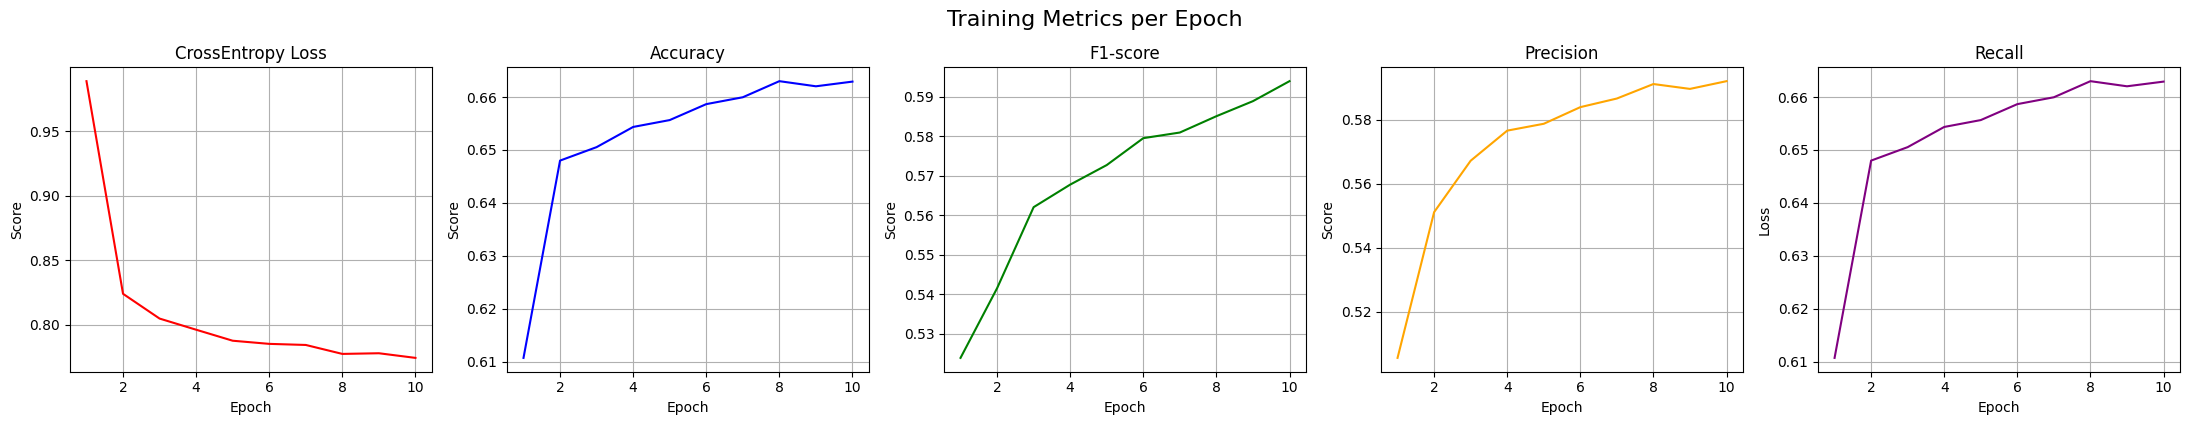

Plotting for label 0


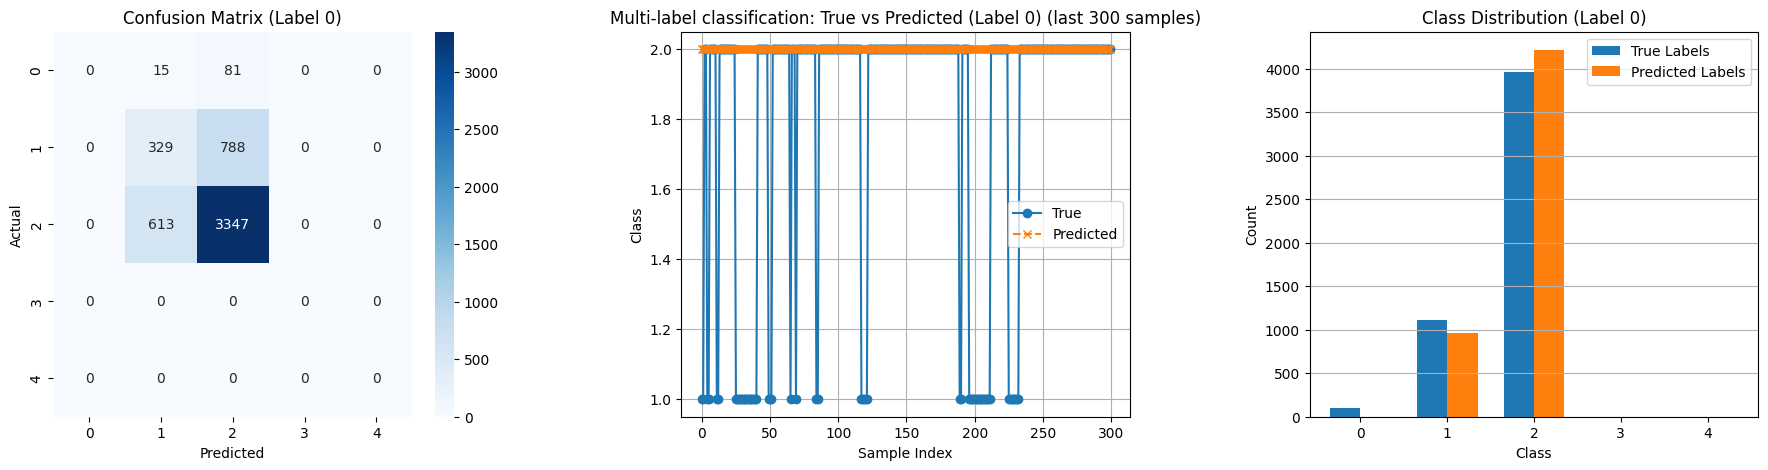

Plotting for label 1


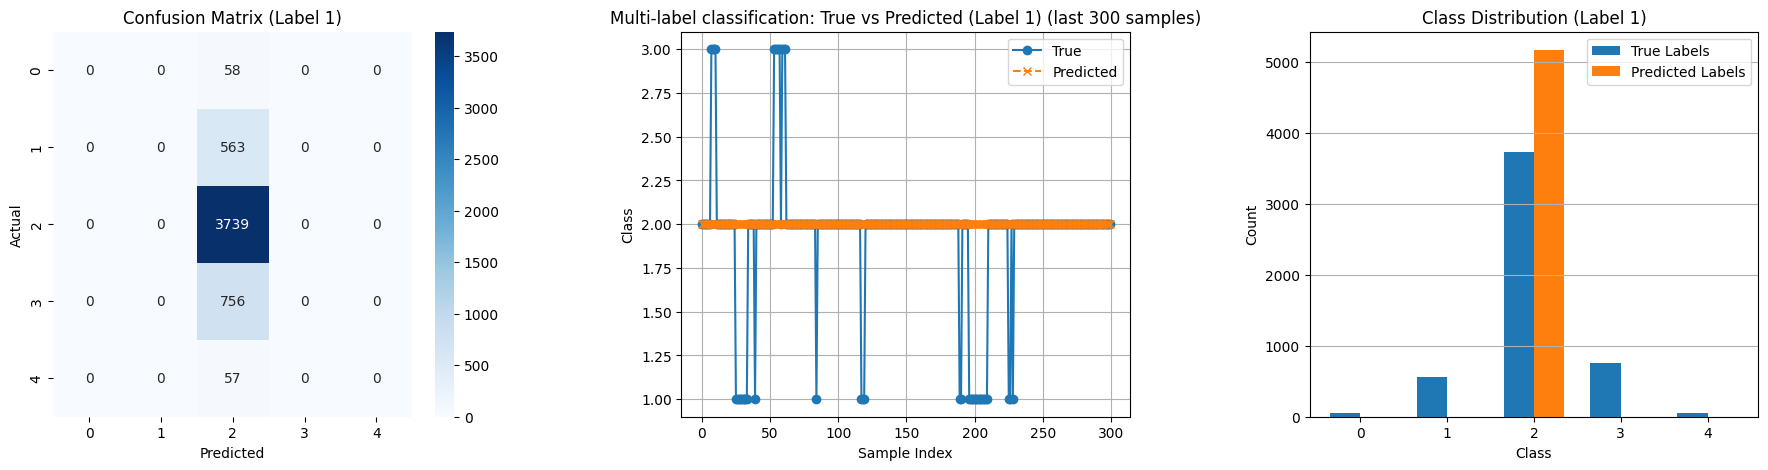

Plotting for label 2


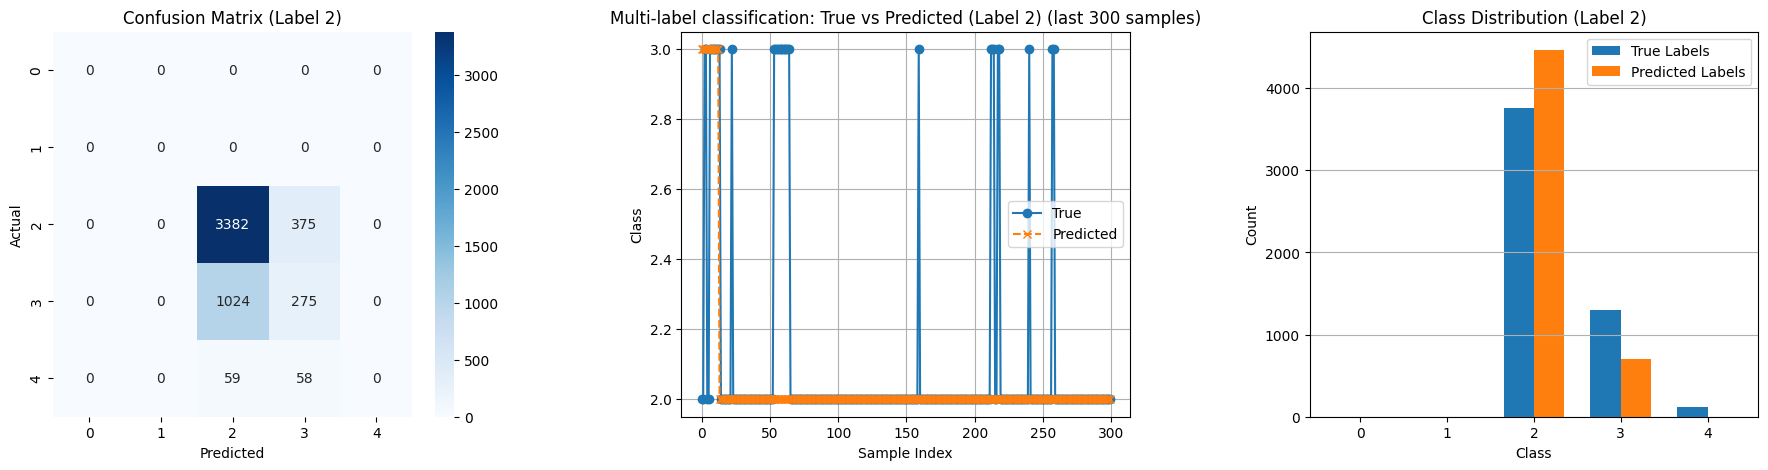

In [ ]:
#-------------------------------------------------------------------------------
# Supprimer les data du train précédent
list = ['model', 'optimiser']
for var in list:
    if var in locals():
        del globals()[var]

#-------------------------------------------------------------------------------

model = LSTM(
    input_dim=feature_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    num_layers=num_layers,
    num_epochs=num_epochs,
    n_labels=n_labels,
    n_categories=n_categories,
    dropout_p=dropout_p
)

#-------------------------------------------------------------------------------

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
model.criterion = nn.CrossEntropyLoss()

#-------------------------------------------------------------------------------

print("---------------------------------")
start_time = time.time()
for t in range(num_epochs):
    model.train()

    epoch_loss = 0.0
    all_preds = []
    all_targets = []

# -------------------------------------------------------

    for x_batch, y_batch in train_loader:
        y_pred_split = model(x_batch)  # tuple/list of 3 tensors
        y_pred = torch.cat(y_pred_split, dim=1)  # → (batch_size, 3×7)

        loss = model.multi_task_loss(y_pred_split, y_batch)
        epoch_loss += loss.item()

        all_preds.append(y_pred.detach().cpu())  # OK maintenant
        all_targets.append(y_batch.detach().cpu())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    y_epoch_pred = torch.cat(all_preds, dim=0)
    y_epoch_true = torch.cat(all_targets, dim=0)
    model.update_metrics(y_epoch_pred, y_epoch_true)

    # ------------------ Validation phase ------------------

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            y_pred_split_val = model(x_val)
            loss_val = model.multi_task_loss(y_pred_split_val, y_val)
            val_loss += loss_val.item()

    val_loss /= len(val_dataset)
    scheduler.step(val_loss)

# -------------------------------------------------------

    if (t+1) % 10 == 0 or t == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {t+1} / Loss: {model.hist_criterion[t]:.4f} / Acc: {model.hist_acc[t]:.4f} / F1: {model.hist_f1[t]:.4f} / Precision: {model.hist_precision[t]:.4f} / Recall: {model.hist_recall[t]:.4f} / LR: {current_lr:.6f}")

# -------------------------------------------------------

training_time = time.time() - start_time
print("---------------------------------")
print(f"Training time: {training_time}")
print("--------------------------------")
#-------------------------------------------------------------------------------

chemin_enregistrement = "lstm_model.pth" # Nom du fichier où enregistrer le modèle
torch.save(model.state_dict(), chemin_enregistrement)
print(f"Modèle enregistré dans : {chemin_enregistrement}")
print("--------------------------------")
#-------------------------------------------------------------------------------

# Get Prediction
y_test_pred, y_test_pred_list = model.get_pred(x_test)

#-------------------------------------------------------------------------------

# Affichage des métriques
model.show_metrics(y_test,y_test_pred,y_test_pred_list)
model.visualize_classification_results(
    y_true=y_test,
    y_pred=y_test_pred,
    n_categories=n_categories,
    sequence_title="Multi-label classification: True vs Predicted",
    max_points=300
)
#-------------------------------------------------------------------------------

# SAC RL

## 🧠 1. ReplayBuffer
Stocke les transitions pour l’apprentissage.

- `__init__(self, capacity)`
- `push(self, state, action, reward, next_state, done)`
- `sample(self, batch_size)`
- `__len__(self)`

---

## ⚙️ 2. Actor (Policy Network)
Propose une politique stochastique π(a|s).

- `__init__(self, state_dim, action_dim)`
- `forward(self, state)`
- `sample(self, state)`

---

## ⚙️ 3. Critic (Q-Networks)
Estime les Q-values (avec deux réseaux Q1 et Q2 typiques du SAC).

- `__init__(self, state_dim, action_dim)`
- `forward(self, state, action)`

---

## ⚙️ 4. ValueNetwork *(optionnel)*
Estime V(s), utilisé dans certaines variantes SAC.

- `__init__(self, state_dim)`
- `forward(self, state)`

---

## 🤖 5. SACAgent
Gère l’apprentissage et l'interaction avec l’environnement.

- `__init__(self, state_dim, action_dim)`
- `select_action(self, state, evaluate=False)`
- `update(self, replay_buffer, batch_size)`
- `save_model(self, path)`
- `load_model(self, path)`

---

## 🏦 6. TradingEnv (Gym Custom Environment)
Simule un environnement de trading long/short avec gestion de SL/TP.

- `__init__(self, df, initial_cash, sl_pct, tp_pct)`
- `reset(self)`
- `step(self, action)`
- `render(self)`
- `get_observation(self)`
- `calculate_reward(self)`

**Actions possibles** :
- `0` = Hold  
- `1` = Long (avec SL/TP)
- `2` = Short (avec SL/TP)

---

## 🏁 7. Trainer / Main Script
Organise les boucles d’entraînement et d’évaluation.

- `train(self, num_episodes)`
- `evaluate(self)`
- `log_results(self)`
- `plot_performance(self)`

In [ ]:
train_test_data = pd.DataFrame({"Feature_1": Labels_Data.data["Price"],
                                "Feature_2": Labels_Data.data["London_Open"],
                                "Feature_3": Labels_Data.data["NY_Open"],
                                "Feature_4": Labels_Data.data["HK_Open"],
                                "Feature_4": Labels_Data.data["Is_Noise"],
                                "Label_1": Labels_Data.data["Category_Low"],
                                "Label_2": Labels_Data.data["Category_Close"],
                                "Label_3": Labels_Data.data["Category_High"]
                                }).dropna()

print(train_test_data.columns)
print(Labels_Data.data.columns)

Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Label_1',
       'Label_2', 'Label_3'],
      dtype='object')
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Quote volume',
       'Number of trades', 'Taker base volume', 'Taker quote volume',
       'VWAP_5m', 'Is_Noise', 'London_Open', 'NY_Open', 'HK_Open', 'Price',
       'Category_Close', 'Category_High', 'Category_Low'],
      dtype='object')


# 📌 Planned Modifications to Apply

## 🧠 Feature Data
- **Add (2 dims):**
  - Distance between Resistance level and Price
  - Distance between Price and Support Level
- **Add (2 dims):**
  - Distance between VWAP POC High and Price
  - Distance between Price and VWAP POC Low

## 🎯 Label Data
- **Change (2 dims):** Replace raw `Low`/`High` with `hit_high` and `hit_low`  
  *(True if high or low is reached within the next x candles)*
- **Add (2 dims):** Add `hit_high_vwap_poc` and `hit_low_vwap_poc`  
  *(True if high or low is reached within the next x candles)*

- **Remove (3 dims):** remove multi Categorization, keep just 2 categories (=Bool) per dim in labels

## 🚀 Performance Optimization
- Standardize variable naming to improve code clarity and maintainability
- Add an optimization loop to test model performance across all variable combinations
- Create Tensorboard Class to plot and centralize all data visualization for LSTM Model